In [1]:
# ==============================================================================
# SECTION 1: IMPORTS & CONFIGURATION
# ==============================================================================

import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

print("=" * 70)
print("🚀 MobileNetV2 Fine-Tuning")
print("=" * 70)

# ==============================================================================
# Paths
# ==============================================================================

PROJECT_ROOT = Path.cwd()

DATASET_DIR = PROJECT_ROOT / "datasets" / "final_split_dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = PROJECT_ROOT / "models"

# ==============================================================================
# Hyperparameters
# ==============================================================================

IMAGE_SIZE = 224
NUM_CLASSES = 9

BATCH_SIZE = 32

# Fine-tuning uses a much smaller learning rate
LEARNING_RATE = 1e-5

NUM_EPOCHS = 15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device        : {DEVICE}")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Epochs        : {NUM_EPOCHS}")

# ==============================================================================
# Random Seed
# ==============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\n✅ Configuration Complete")

C:\Users\vnman\Desktop\virtual-internship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 MobileNetV2 Fine-Tuning
Device        : cuda
Learning Rate : 1e-05
Epochs        : 15

✅ Configuration Complete


In [3]:
# ==============================================================================
# SECTION 2: DATASET & DATALOADERS
# ==============================================================================

print("=" * 70)
print("📂 Loading Dataset")
print("=" * 70)

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==============================================================================
# Project Paths
# ==============================================================================

# Notebook is inside:
# virtual-internship/notebooks/
# So go one level up to reach the project root.

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "datasets" / "final_split_dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = PROJECT_ROOT / "models"

# ==============================================================================
# Verify Paths
# ==============================================================================

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATASET_DIR)
print("Model Path   :", MODEL_DIR)

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation folder not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

# ==============================================================================
# Image Transformations
# ==============================================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==============================================================================
# Load Datasets
# ==============================================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transforms
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transforms
)

# ==============================================================================
# DataLoaders
# ==============================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset Loaded Successfully\n")

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print("\nClasses:")
print(train_dataset.classes)

print("\n✅ Dataset Ready")

📂 Loading Dataset
Project Root : C:\Users\vnman\Desktop\virtual-internship
Dataset Path : C:\Users\vnman\Desktop\virtual-internship\datasets\final_split_dataset
Model Path   : C:\Users\vnman\Desktop\virtual-internship\models

Dataset Loaded Successfully

Training Images   : 7560
Validation Images : 1308
Testing Images    : 1308

Classes:
['Blackheads', 'Dark_Spots', 'Inflammatory_Acne', 'Normal', 'Pigmentation', 'Pores', 'Redness', 'Whiteheads', 'Wrinkles']

✅ Dataset Ready


In [4]:
# ==============================================================================
# SECTION 3: LOAD BEST MODEL & PREPARE FOR FINE-TUNING
# ==============================================================================

print("=" * 70)
print("🧠 Loading Best Model for Fine-Tuning")
print("=" * 70)

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# ==============================================================================
# Create Model
# ==============================================================================

model = mobilenet_v2(weights=None)

# Replace classifier
model.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=NUM_CLASSES
)

# ==============================================================================
# Load Previously Trained Weights
# ==============================================================================

model.load_state_dict(
    torch.load(
        MODEL_DIR / "mobilenetv2_best.pth",
        map_location=DEVICE
    )
)

print("✅ Best model loaded successfully")

# ==============================================================================
# Freeze Entire Network
# ==============================================================================

for param in model.parameters():
    param.requires_grad = False

# ==============================================================================
# Unfreeze ONLY the Last Feature Block
# ==============================================================================

for param in model.features[-1].parameters():
    param.requires_grad = True

# Always train classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# ==============================================================================
# Move to GPU
# ==============================================================================

model = model.to(DEVICE)

# ==============================================================================
# Count Parameters
# ==============================================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print("\n✅ Fine-Tuning Model Ready")

🧠 Loading Best Model for Fine-Tuning
✅ Best model loaded successfully
Total Parameters      : 2,235,401
Trainable Parameters  : 423,689

✅ Fine-Tuning Model Ready


In [5]:
# ==============================================================================
# SECTION 4: LOSS FUNCTION, OPTIMIZER & SCHEDULER
# ==============================================================================

print("=" * 70)
print("⚙️ Configuring Fine-Tuning")
print("=" * 70)

# ==============================================================================
# Loss Function
# ==============================================================================

criterion = nn.CrossEntropyLoss()

# ==============================================================================
# Optimizer
# ==============================================================================

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ==============================================================================
# Learning Rate Scheduler
# ==============================================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print(f"Loss Function : {criterion.__class__.__name__}")
print(f"Optimizer     : {optimizer.__class__.__name__}")
print(f"Learning Rate : {LEARNING_RATE}")

print("\n✅ Fine-Tuning Configuration Complete")

⚙️ Configuring Fine-Tuning
Loss Function : CrossEntropyLoss
Optimizer     : AdamW
Learning Rate : 1e-05

✅ Fine-Tuning Configuration Complete


In [6]:
# ==============================================================================
# SECTION 8: TRAINING & VALIDATION FUNCTIONS
# ==============================================================================

print("=" * 70)
print("🏋️ Defining Training & Validation Functions")
print("=" * 70)


# ==============================================================================
# Training Function
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


# ==============================================================================
# Validation Function
# ==============================================================================

def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


print("\n✅ Training Function Created")
print("✅ Validation Function Created")

print("\n" + "=" * 70)
print("✅ Section Completed Successfully")
print("=" * 70)

🏋️ Defining Training & Validation Functions

✅ Training Function Created
✅ Validation Function Created

✅ Section Completed Successfully


In [7]:
# ==============================================================================
# SECTION 9: MAIN FINE-TUNING LOOP
# ==============================================================================

print("=" * 70)
print("🚀 Starting MobileNetV2 Fine-Tuning")
print("=" * 70)

# ==============================================================================
# Variables
# ==============================================================================

best_val_loss = float("inf")
early_stop_counter = 0
EARLY_STOPPING_PATIENCE = 7

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# ==============================================================================
# Fine-Tuning Loop
# ==============================================================================

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("-" * 70)

    # --------------------------------------------------------------------------
    # Training
    # --------------------------------------------------------------------------

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # --------------------------------------------------------------------------
    # Validation
    # --------------------------------------------------------------------------

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # --------------------------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------------------------

    scheduler.step(val_loss)

    # --------------------------------------------------------------------------
    # Store History
    # --------------------------------------------------------------------------

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # --------------------------------------------------------------------------
    # Print Metrics
    # --------------------------------------------------------------------------

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_acc:.2f}%")
    print(f"Learning Rate  : {optimizer.param_groups[0]['lr']:.6f}")

    # --------------------------------------------------------------------------
    # Save Best Model
    # --------------------------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(
            model.state_dict(),
            MODEL_DIR / "mobilenetv2_finetuned_best.pth"
        )

        print("✅ New Best Fine-Tuned Model Saved")

    else:

        early_stop_counter += 1
        print(
            f"No improvement ({early_stop_counter}/{EARLY_STOPPING_PATIENCE})"
        )

    # --------------------------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------------------------

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n🛑 Early stopping triggered.")
        break

print("\n" + "=" * 70)
print("🎉 Fine-Tuning Completed")
print("=" * 70)

print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"Fine-Tuned Model Saved At : {MODEL_DIR / 'mobilenetv2_finetuned_best.pth'}")

🚀 Starting MobileNetV2 Fine-Tuning

Epoch [1/15]
----------------------------------------------------------------------


Train Loss     : 0.3925
Train Accuracy : 81.69%
Val Loss       : 0.4295
Val Accuracy   : 79.13%
Learning Rate  : 0.000010
✅ New Best Fine-Tuned Model Saved

Epoch [2/15]
----------------------------------------------------------------------


Train Loss     : 0.3783
Train Accuracy : 81.97%
Val Loss       : 0.4345
Val Accuracy   : 79.28%
Learning Rate  : 0.000010
No improvement (1/7)

Epoch [3/15]
----------------------------------------------------------------------


Train Loss     : 0.3822
Train Accuracy : 81.81%
Val Loss       : 0.4352
Val Accuracy   : 79.59%
Learning Rate  : 0.000010
No improvement (2/7)

Epoch [4/15]
----------------------------------------------------------------------


Train Loss     : 0.3659
Train Accuracy : 82.50%
Val Loss       : 0.4193
Val Accuracy   : 79.66%
Learning Rate  : 0.000010
✅ New Best Fine-Tuned Model Saved

Epoch [5/15]
----------------------------------------------------------------------


...

Train Loss     : 0.3606
Train Accuracy : 82.45%
Val Loss       : 0.4171
Val Accuracy   : 79.59%
Learning Rate  : 0.000010
No improvement (1/7)

Epoch [12/15]
----------------------------------------------------------------------


Train Loss     : 0.3556
Train Accuracy : 82.51%
Val Loss       : 0.4116
Val Accuracy   : 79.82%
Learning Rate  : 0.000010
✅ New Best Fine-Tuned Model Saved

Epoch [13/15]
----------------------------------------------------------------------


Train Loss     : 0.3631
Train Accuracy : 82.28%
Val Loss       : 0.4086
Val Accuracy   : 80.28%
Learning Rate  : 0.000010
✅ New Best Fine-Tuned Model Saved

Epoch [14/15]
----------------------------------------------------------------------


Train Loss     : 0.3489
Train Accuracy : 82.54%
Val Loss       : 0.4114
Val Accuracy   : 79.82%
Learning Rate  : 0.000010
No improvement (1/7)

Epoch [15/15]
----------------------------------------------------------------------


Train Loss     : 0.3422
Train Accuracy : 83.28%
Val Loss       : 0.4102
Val Accuracy   : 79.97%
Learning Rate  : 0.000010
No improvement (2/7)

🎉 Fine-Tuning Completed
Best Validation Loss : 0.4086
Fine-Tuned Model Saved At : C:\Users\vnman\Desktop\virtual-internship\models\mobilenetv2_finetuned_best.pth


In [8]:
# ==============================================================================
# SECTION 10: LOAD BEST FINE-TUNED MODEL
# ==============================================================================

print("=" * 70)
print("📦 Loading Best Fine-Tuned Model")
print("=" * 70)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "mobilenetv2_finetuned_best.pth",
        map_location=DEVICE
    )
)

model = model.to(DEVICE)
model.eval()

print("✅ Fine-Tuned Model Loaded Successfully")

📦 Loading Best Fine-Tuned Model
✅ Fine-Tuned Model Loaded Successfully


In [9]:
# ==============================================================================
# SECTION 11: TEST EVALUATION
# ==============================================================================

print("=" * 70)
print("🧪 Evaluating Fine-Tuned Model")
print("=" * 70)

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= total
test_accuracy = 100 * correct / total

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

print("\n✅ Evaluation Complete")

🧪 Evaluating Fine-Tuned Model


100%|██████████| 41/41 [00:11<00:00,  3.54it/s]



Test Loss     : 0.4026
Test Accuracy : 79.05%

✅ Evaluation Complete


In [10]:
# ==============================================================================
# SECTION 12: CLASSIFICATION REPORT
# ==============================================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("📊 Classification Report")
print("=" * 70)

report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    digits=4
)

print(report)

📊 Classification Report
                   precision    recall  f1-score   support

       Blackheads     0.8671    0.8333    0.8499       180
       Dark_Spots     0.4944    0.4944    0.4944       180
Inflammatory_Acne     0.8324    0.8278    0.8301       180
           Normal     0.9202    0.9611    0.9402       180
     Pigmentation     0.4938    0.4444    0.4678       180
            Pores     0.9574    1.0000    0.9783       180
          Redness     0.8000    1.0000    0.8889         4
       Whiteheads     0.8039    0.9318    0.8632        44
         Wrinkles     0.9231    0.9333    0.9282       180

         accuracy                         0.7905      1308
        macro avg     0.7880    0.8251    0.8045      1308
     weighted avg     0.7848    0.7905    0.7871      1308



<Figure size 1000x800 with 0 Axes>

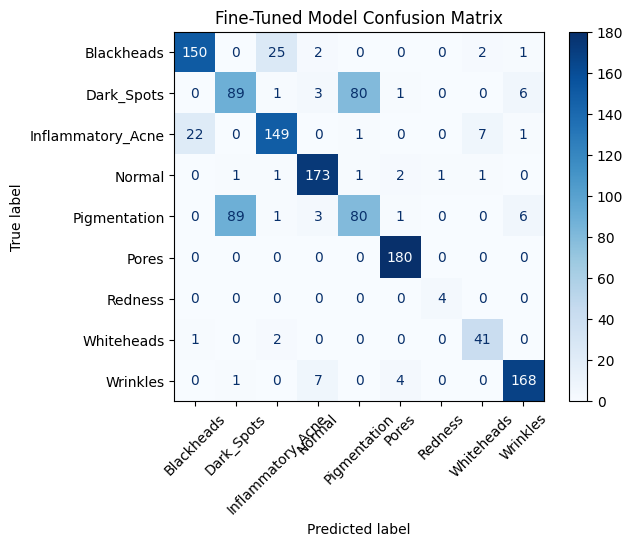

In [11]:
# ==============================================================================
# SECTION 13: CONFUSION MATRIX
# ==============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Fine-Tuned Model Confusion Matrix")
plt.show()

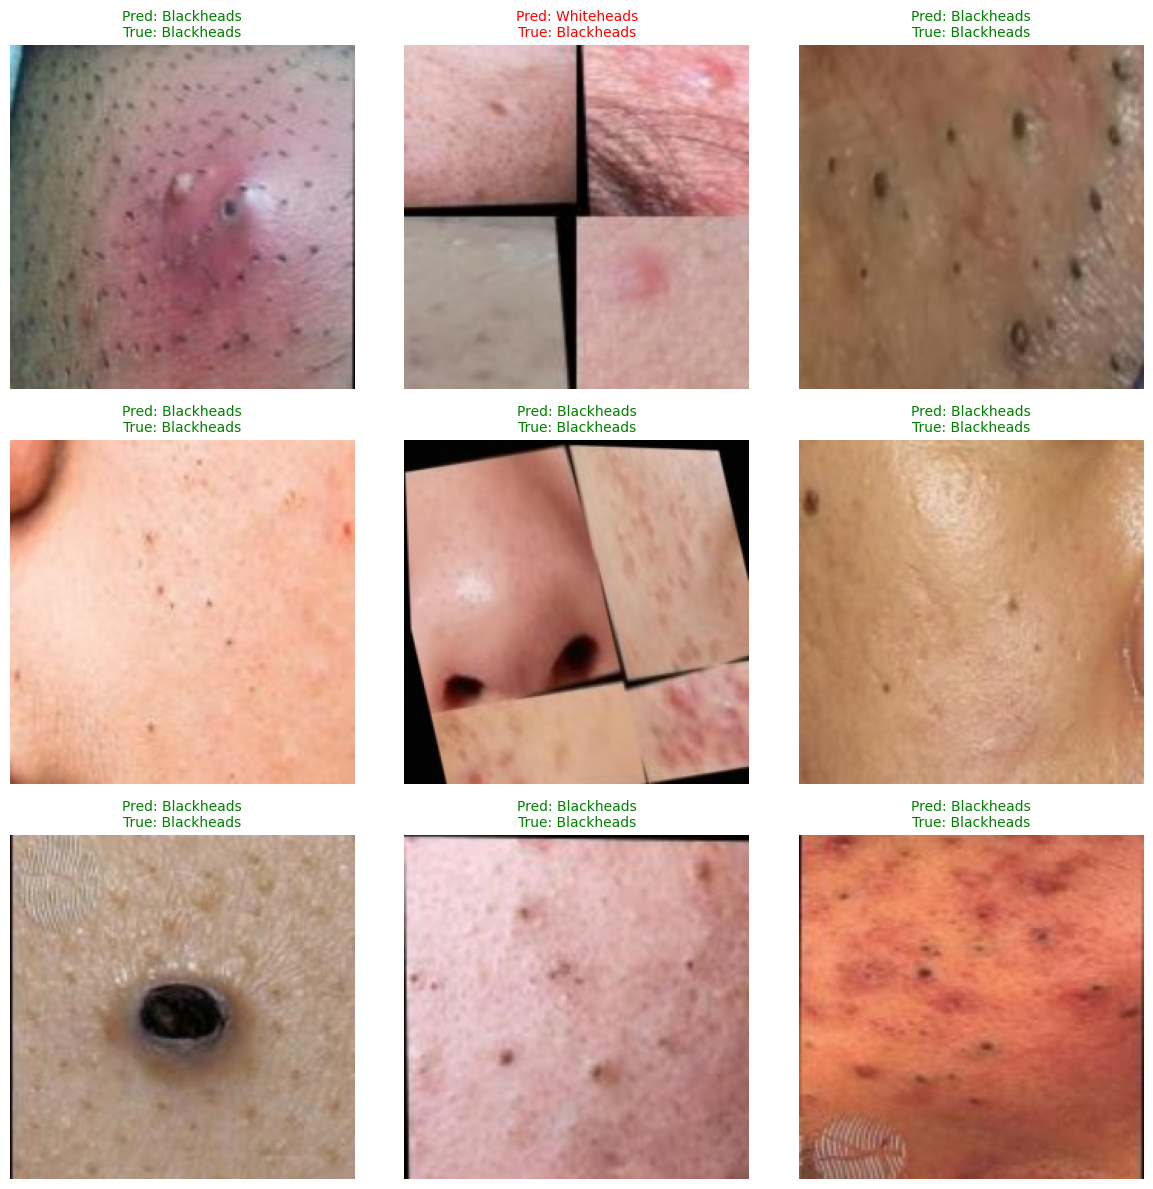

In [12]:
# ==============================================================================
# SECTION 14: SAMPLE PREDICTIONS
# ==============================================================================

class_names = test_dataset.classes

images, labels = next(iter(test_loader))

images = images.to(DEVICE)

model.eval()

with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

images = images.cpu()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    img = images[i].permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    pred = class_names[predictions[i].item()]
    true = class_names[labels[i].item()]

    color = "green" if pred == true else "red"

    plt.title(
        f"Pred: {pred}\nTrue: {true}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()